# Early Warning Risiko Mahasiswa OULAD
## Evaluasi Model, Knowledge-Based System, dan Dashboard DVBI

**Mata Kuliah:** Data Visualization and Business Intelligence  
**Kelompok:** 5  
**Program Studi:** S2 PJJ Informatika, Konsentrasi Big Data dan Predictive Analytics  
**Institusi:** Universitas Amikom Yogyakarta

| Nama | NIM |
|---|---|
| Muhammad Rizky Hajar | 24.55.2714 |
| Alwie Muflich | 24.55.2667 |
| Heri Santosa | 24.55.2676 |

**Tujuan notebook:** memprediksi mahasiswa berisiko pada akhir minggu ke-4, membandingkan tiga model supervised learning, memilih model dengan *recall* `AtRisk` terbaik, lalu menerjemahkan hasilnya menjadi sistem berbasis pengetahuan dan dashboard pendukung keputusan.

**Definisi target:** `AtRisk` = `Withdrawn` atau `Fail`; `Successful` = `Pass` atau `Distinction`.

> Hasil model berfungsi sebagai **decision support**. Dosen, tutor, dan pengelola akademik menetapkan keputusan intervensi berdasarkan hasil analisis dan pertimbangan akademik.

## 1. Persiapan library

**Tujuan:** menyiapkan seluruh library dan parameter eksperimen.

**Langkah:** mengimpor library pengolahan data, visualisasi, preprocessing, evaluasi, dan tiga algoritma klasifikasi. `RANDOM_STATE=42` menjaga hasil tetap dapat direproduksi, sedangkan `CUTOFF_DAY=28` membatasi data hingga akhir minggu ke-4.

**Output:** pesan konfigurasi eksperimen.



In [1]:
# Library standar untuk file, download, ekstraksi zip, dan pengaturan warning.
import os, shutil, urllib.request, zipfile, warnings
from pathlib import Path
from collections import Counter

# Library utama untuk manipulasi data dan visualisasi.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Komponen scikit-learn dan XGBoost untuk preprocessing, model, split, dan evaluasi.
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Pengaturan tampilan agar output notebook lebih rapi saat dipresentasikan.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 100)

# Parameter eksperimen: seed reproduksibilitas dan batas early warning minggu ke-4.
RANDOM_STATE = 42
CUTOFF_DAY = 28
DATA_DIR = Path('/content/oulad')
print(f'Konfigurasi: random_state={RANDOM_STATE}, cutoff={CUTOFF_DAY} hari')

Konfigurasi: random_state=42, cutoff=28 hari


## 2. Mengunduh dataset OULAD

**Tujuan:** memperoleh data tanpa upload manual atau Google Drive.

**Langkah:** mengunduh arsip OULAD dari UCI Machine Learning Repository, mengekstraknya, dan memastikan tujuh file sumber tersedia. Download dilewati bila file sudah ada dalam runtime.

**Output:** daftar file CSV dan status validasi.



In [2]:
# Lokasi dataset dan daftar file yang harus tersedia setelah ekstraksi.
DATA_URL = 'https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip'
ZIP_PATH = Path('/content/anonymisedData.zip')
EXPECTED_FILES = {'assessments.csv', 'courses.csv', 'studentAssessment.csv',
                  'studentInfo.csv', 'studentRegistration.csv',
                  'studentVle.csv', 'vle.csv'}

# Cek isi folder data; download hanya dilakukan jika file belum lengkap.
DATA_DIR.mkdir(parents=True, exist_ok=True)
available = {p.name for p in DATA_DIR.glob('*.csv')}
if not EXPECTED_FILES.issubset(available):
    print('Mengunduh OULAD...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

# Validasi akhir memastikan seluruh file CSV sumber sudah tersedia.
available = {p.name for p in DATA_DIR.glob('*.csv')}
missing = EXPECTED_FILES - available
assert not missing, f'File dataset tidak lengkap: {sorted(missing)}'
print('Dataset siap:', ', '.join(sorted(EXPECTED_FILES)))

Dataset siap: assessments.csv, courses.csv, studentAssessment.csv, studentInfo.csv, studentRegistration.csv, studentVle.csv, vle.csv


## 3. Membaca dan memeriksa data sumber

**Tujuan:** memahami ukuran dan struktur tabel yang dipakai.

**Langkah:** membaca empat tabel utama. `studentInfo` memuat profil dan hasil akhir, `studentRegistration` memuat tanggal registrasi, `assessments` memberi konteks modul, dan dua tabel aktivitas menyediakan perilaku assessment serta VLE.

**Output:** jumlah baris dan kolom setiap tabel.



In [3]:
# Baca tabel sumber yang dipakai untuk profil, registrasi, assessment, dan aktivitas VLE.
student_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
registration = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
assessments = pd.read_csv(DATA_DIR / 'assessments.csv')
student_assessment = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
student_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

# Ringkas ukuran tiap tabel agar struktur data awal mudah diperiksa.
source_summary = pd.DataFrame({
    'tabel': ['studentInfo', 'studentRegistration', 'assessments', 'studentAssessment', 'studentVle'],
    'baris': [len(student_info), len(registration), len(assessments), len(student_assessment), len(student_vle)],
    'kolom': [student_info.shape[1], registration.shape[1], assessments.shape[1],
              student_assessment.shape[1], student_vle.shape[1]]
})
display(source_summary.style.format(thousands=','))

,tabel,baris,kolom
0,studentInfo,"32,593",12
1,studentRegistration,"32,593",5
2,assessments,206,6
3,studentAssessment,"173,912",5
4,studentVle,"10,655,280",6


## 4. Membentuk dataset early warning minggu ke-4

**Tujuan:** melakukan preprocessing tahap pertama, yaitu mengubah data mentah OULAD menjadi dataset analisis dengan fitur yang hanya tersedia sampai hari ke-28.

**Langkah:** target `AtRisk` dibentuk dari hasil akhir, assessment difilter memakai `date_submitted <= 28`, dan aktivitas VLE difilter memakai `date <= 28`. Data kemudian diagregasi per mahasiswa, modul, dan presentation. Fitur model berfokus pada informasi yang tersedia hingga hari ke-28; tanggal unregistration dikeluarkan karena bersifat post-hoc.

**Output:** ukuran dataset, jumlah mahasiswa unik, dan daftar fitur.



In [4]:
KEYS = ['code_module', 'code_presentation', 'id_student']

# Target biner berasal dari hasil akhir; fitur prediktor menggunakan data yang tersedia sampai hari ke-28.
base = student_info.copy()
base['risk_label'] = np.where(base['final_result'].isin(['Withdrawn', 'Fail']), 'AtRisk', 'Successful')

# Fitur registrasi yang tersedia sebelum/awal perkuliahan; unregistration sengaja dikeluarkan.
reg_features = registration[KEYS + ['date_registration']].copy()

# Hubungkan submission ke konteks module-presentation, lalu batasi sampai hari ke-28.
student_assessment['date_submitted'] = pd.to_numeric(student_assessment['date_submitted'], errors='coerce')
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')
assessment_early = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment', how='left'
)
assessment_early = assessment_early[assessment_early['date_submitted'] <= CUTOFF_DAY]
assessment_features = (assessment_early.groupby(KEYS)
    .agg(assessment_count=('id_assessment', 'count'),
         assessment_score_mean=('score', 'mean'),
         assessment_score_max=('score', 'max'),
         assessment_score_min=('score', 'min'))
    .reset_index())

# Aktivitas VLE juga dibatasi sampai hari ke-28.
student_vle['date'] = pd.to_numeric(student_vle['date'], errors='coerce')
student_vle['sum_click'] = pd.to_numeric(student_vle['sum_click'], errors='coerce').fillna(0)
vle_early = student_vle[student_vle['date'] <= CUTOFF_DAY].copy()
vle_features = (vle_early.groupby(KEYS)
    .agg(vle_total_clicks=('sum_click', 'sum'),
         vle_active_days=('date', 'nunique'),
         vle_site_count=('id_site', 'nunique'),
         vle_last_activity_day=('date', 'max'))
    .reset_index())

dataset = (base.merge(reg_features, on=KEYS, how='left')
               .merge(assessment_features, on=KEYS, how='left')
               .merge(vle_features, on=KEYS, how='left'))

behavior_cols = ['assessment_count', 'assessment_score_mean', 'assessment_score_max',
                 'assessment_score_min', 'vle_total_clicks', 'vle_active_days',
                 'vle_site_count', 'vle_last_activity_day']
dataset[behavior_cols] = dataset[behavior_cols].fillna(0)

print(f'Unit analisis: {len(dataset):,} student-module-presentation')
print(f'Mahasiswa unik: {dataset.id_student.nunique():,}')
display(dataset.head())

Unit analisis: 32,593 student-module-presentation
Mahasiswa unik: 28,785


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,risk_label,date_registration,assessment_count,assessment_score_mean,assessment_score_max,assessment_score_min,vle_total_clicks,vle_active_days,vle_site_count,vle_last_activity_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,Successful,-159.0,1.0,78.0,78.0,78.0,401.0,8.0,24.0,18.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,Successful,-53.0,1.0,70.0,70.0,70.0,618.0,19.0,34.0,28.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,AtRisk,-92.0,0.0,0.0,0.0,0.0,281.0,12.0,22.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,Successful,-52.0,1.0,72.0,72.0,72.0,494.0,22.0,31.0,28.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,Successful,-176.0,1.0,69.0,69.0,69.0,567.0,24.0,34.0,26.0


## 5. Validasi anti-leakage

**Tujuan:** memastikan seluruh fitur prediktor tersedia pada atau sebelum hari ke-28.

**Langkah:** mendefinisikan fitur model secara eksplisit dan memastikan daftar prediktor terbatas pada data demografis, registrasi awal, assessment awal, dan aktivitas VLE awal.

**Output:** status `LULUS` dan daftar fitur kategorikal/numerik.



In [5]:
# Pisahkan fitur kategorikal dan numerik untuk preprocessing yang berbeda.
CATEGORICAL_COLS = ['gender', 'region', 'highest_education', 'imd_band',
                    'age_band', 'disability', 'code_module', 'code_presentation']
NUMERIC_COLS = ['num_of_prev_attempts', 'studied_credits', 'date_registration',
                'assessment_count', 'assessment_score_mean', 'assessment_score_max',
                'assessment_score_min', 'vle_total_clicks', 'vle_active_days',
                'vle_site_count', 'vle_last_activity_day']
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
# Kolom berikut tidak boleh menjadi prediktor karena berisi target atau informasi post-hoc.
FORBIDDEN = {'final_result', 'risk_label', 'date_unregistration', 'has_unregistration'}

# Validasi anti-leakage: fitur model harus bebas dari target dan data setelah hari ke-28.
assert not FORBIDDEN.intersection(FEATURE_COLS)
assert vle_early['date'].max() <= CUTOFF_DAY
assert assessment_early['date_submitted'].max() <= CUTOFF_DAY
print('LULUS: tidak ada fitur target, unregistration, atau aktivitas setelah hari ke-28.')
print('Fitur kategorikal:', CATEGORICAL_COLS)
print('Fitur numerik:', NUMERIC_COLS)

LULUS: tidak ada fitur target, unregistration, atau aktivitas setelah hari ke-28.
Fitur kategorikal: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']
Fitur numerik: ['num_of_prev_attempts', 'studied_credits', 'date_registration', 'assessment_count', 'assessment_score_mean', 'assessment_score_max', 'assessment_score_min', 'vle_total_clicks', 'vle_active_days', 'vle_site_count', 'vle_last_activity_day']


## 6. Exploratory Data Analysis

**Tujuan:** melihat kualitas data dan pola awal risiko.

**Langkah:** menampilkan distribusi kelas, missing values, dan median perilaku minggu ke-4 untuk kedua kelas.

**Output:** keseimbangan target serta perbedaan assessment dan VLE antara `AtRisk` dan `Successful`.



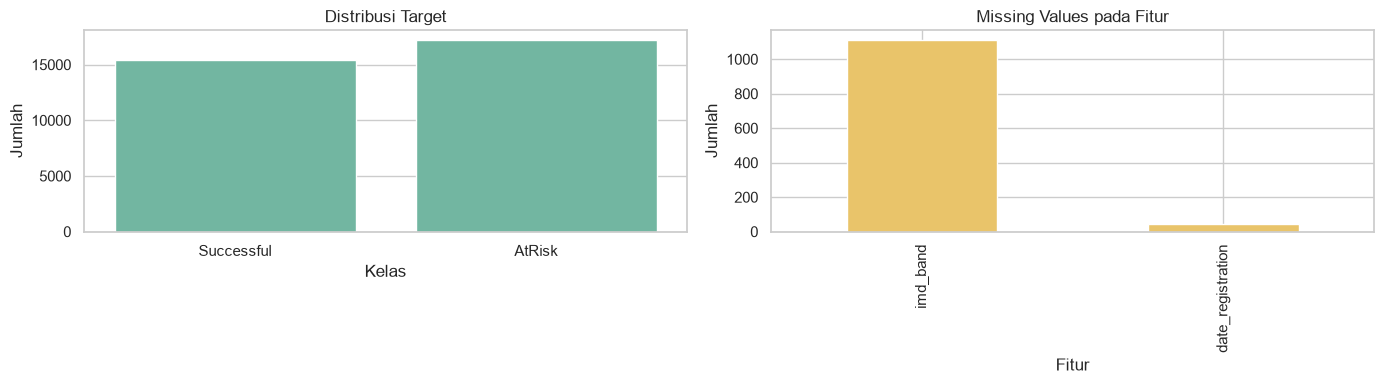

,assessment_count,assessment_score_mean,vle_total_clicks,vle_active_days
risk_label,,,,
AtRisk,1.0,0.0,92.0,7.0
Successful,1.0,76.0,298.0,16.0


risk_label
AtRisk        17208
Successful    15385
Name: count, dtype: int64


In [6]:
# Hitung missing value, distribusi target, dan median perilaku awal per kelas.
missing_summary = dataset[FEATURE_COLS].isna().sum().sort_values(ascending=False)
class_counts = dataset['risk_label'].value_counts()
behavior_by_class = dataset.groupby('risk_label')[
    ['assessment_count', 'assessment_score_mean', 'vle_total_clicks', 'vle_active_days']
].median().round(2)

# Tampilkan distribusi kelas dan kondisi missing value sebagai ringkasan EDA awal.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=dataset, x='risk_label', order=['Successful', 'AtRisk'], ax=axes[0])
axes[0].set_title('Distribusi Target')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah')
missing_nonzero = missing_summary[missing_summary > 0]
if missing_nonzero.empty:
    axes[1].text(0.5, 0.55, 'Kelengkapan fitur: 100%', ha='center', va='center',
                 fontsize=18, fontweight='bold', color='#2A9D8F')
    axes[1].text(0.5, 0.40, 'Seluruh fitur siap digunakan', ha='center', va='center')
    axes[1].set_axis_off()
else:
    missing_nonzero.plot(kind='bar', ax=axes[1], color='#E9C46A')
    axes[1].set_title('Missing Values pada Fitur')
    axes[1].set_xlabel('Fitur'); axes[1].set_ylabel('Jumlah')
plt.tight_layout(); plt.show()
# Tabel median membantu membandingkan perilaku minggu ke-4 antara kelas risiko.
display(behavior_by_class)
print(class_counts)

## 7. Pembagian data berdasarkan mahasiswa

**Tujuan:** membuat evaluasi hold-out yang adil.

**Langkah:** membagi 80% train-validation dan 20% test menggunakan `id_student` sebagai grup. Setiap mahasiswa ditempatkan secara eksklusif pada salah satu bagian walaupun mengambil lebih dari satu modul.

**Output:** ukuran split dan jumlah overlap mahasiswa yang harus bernilai nol.



In [7]:
# Pastikan seluruh fitur numerik siap diproses oleh pipeline model.
for column in NUMERIC_COLS:
    dataset[column] = pd.to_numeric(dataset[column], errors='coerce')

# Bentuk matriks fitur, target biner, dan grup mahasiswa untuk split berbasis id_student.
X = dataset[FEATURE_COLS].copy()
y = dataset['risk_label'].map({'Successful': 0, 'AtRisk': 1})
groups = dataset['id_student']

# Split 80:20 berbasis mahasiswa agar id_student yang sama tidak muncul di train dan test.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

# Cek overlap mahasiswa sebagai validasi bahwa split berbasis grup berhasil.
train_students = set(groups.iloc[train_idx])
test_students = set(groups.iloc[test_idx])
overlap = train_students.intersection(test_students)
assert len(overlap) == 0
print(f'Train-validation: {len(X_train):,} baris | Test: {len(X_test):,} baris')
print(f'Overlap mahasiswa: {len(overlap)}')
print('Distribusi train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Distribusi test :', y_test.value_counts(normalize=True).round(3).to_dict())

Train-validation: 26,122 baris | Test: 6,471 baris
Overlap mahasiswa: 0
Distribusi train: {1: 0.529, 0: 0.471}
Distribusi test : {1: 0.525, 0: 0.475}


## 8. Pipeline preprocessing dan model

**Tujuan:** melakukan preprocessing tahap kedua untuk input machine learning, lalu mendefinisikan tiga model secara konsisten.

**Langkah:** nilai numerik diimputasi dengan median dan distandardisasi; kategori diimputasi dan diubah dengan one-hot encoding. Semua transformasi berada di dalam pipeline sehingga hanya belajar dari data train pada setiap fold.

**Output:** nama tiga model pembanding.



In [8]:
# Fitur numerik diimputasi lalu distandardisasi.
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Fitur kategorikal diimputasi lalu diubah menjadi one-hot encoding.
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# ColumnTransformer menerapkan pipeline sesuai tipe fitur.
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, NUMERIC_COLS),
    ('categorical', categorical_pipe, CATEGORICAL_COLS)
])

# Bobot kelas membantu model memberi perhatian pada kelas AtRisk.
negative, positive = np.bincount(y_train)
scale_pos_weight = negative / positive
# Tiga model dibandingkan dengan konfigurasi yang konsisten.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1500, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.08,
                             subsample=0.9, colsample_bytree=0.9,
                             scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                             random_state=RANDOM_STATE, n_jobs=-1)
}
# Gabungkan preprocessing dan model agar transformasi hanya belajar dari data train.
pipelines = {name: Pipeline([('preprocess', clone(preprocessor)), ('model', model)])
             for name, model in models.items()}
print('Model:', ', '.join(pipelines))

Model: Logistic Regression, Random Forest, XGBoost


## 9. Cross-validation lima fold

**Tujuan:** mengukur kestabilan model pada beberapa pembagian data latih.

**Langkah:** setiap model dievaluasi dengan lima fold berbasis kelompok mahasiswa. Metrik utama adalah recall `AtRisk`; F1 digunakan sebagai tie-breaker.

**Output:** rata-rata dan standar deviasi accuracy, precision, recall, F1, dan ROC-AUC.



In [9]:
# Fungsi ini menyatukan metrik yang dipakai berulang pada CV dan hold-out test.
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_atrisk': precision_score(y_true, y_pred, zero_division=0),
        'recall_atrisk': recall_score(y_true, y_pred, zero_division=0),
        'f1_atrisk': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

# GroupKFold menjaga mahasiswa yang sama tetap berada dalam fold yang sama.
gkf = GroupKFold(n_splits=5)
cv_rows = []
for model_name, pipeline in pipelines.items():
    for fold, (fit_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train), start=1):
        fold_model = clone(pipeline)
        fold_model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        pred = fold_model.predict(X_train.iloc[val_idx])
        prob = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
        cv_rows.append({'model': model_name, 'fold': fold,
                        **calculate_metrics(y_train.iloc[val_idx], pred, prob)})

# Ringkas hasil tiap fold menjadi rata-rata dan standar deviasi per model.
cv_detail = pd.DataFrame(cv_rows)
cv_summary = cv_detail.groupby('model').agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    precision_mean=('precision_atrisk', 'mean'), precision_std=('precision_atrisk', 'std'),
    recall_mean=('recall_atrisk', 'mean'), recall_std=('recall_atrisk', 'std'),
    f1_mean=('f1_atrisk', 'mean'), f1_std=('f1_atrisk', 'std'),
    roc_auc_mean=('roc_auc', 'mean'), roc_auc_std=('roc_auc', 'std')
).sort_values(['recall_mean', 'f1_mean'], ascending=False)
display(cv_summary.style.format('{:.4f}').highlight_max(subset=['recall_mean', 'f1_mean'], color='#B7E4C7'))

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Random Forest,0.7538,0.0033,0.7999,0.0148,0.7126,0.0040,0.7536,0.0050,0.8362,0.0026
XGBoost,0.7582,0.0041,0.8217,0.0093,0.6931,0.0033,0.7519,0.0028,0.8440,0.0020
Logistic Regression,0.7484,0.0033,0.8081,0.0063,0.6871,0.0038,0.7427,0.0043,0.8324,0.0028


## 10. Evaluasi akhir pada hold-out test

**Tujuan:** membandingkan generalisasi ketiga model pada data yang belum pernah dilihat.

**Langkah:** model dipilih dari hasil cross-validation berdasarkan recall dan F1 `AtRisk`, kemudian dilatih pada seluruh train-validation. Hold-out test digunakan untuk mengukur generalisasi akhir dan menampilkan perbandingan model.

**Output:** tabel metrik dan nama model terbaik.



In [10]:
# Latih ulang setiap model pada seluruh train-validation, lalu prediksi hold-out test.
fitted_models, test_predictions, test_probabilities, test_rows = {}, {}, {}, []
for model_name, pipeline in pipelines.items():
    fitted = clone(pipeline).fit(X_train, y_train)
    pred = fitted.predict(X_test)
    prob = fitted.predict_proba(X_test)[:, 1]
    fitted_models[model_name] = fitted
    test_predictions[model_name] = pred
    test_probabilities[model_name] = prob
    test_rows.append({'model': model_name, **calculate_metrics(y_test, pred, prob)})

# Urutkan hasil test berdasarkan recall AtRisk dan F1.
test_results = pd.DataFrame(test_rows).set_index('model').sort_values(
    ['recall_atrisk', 'f1_atrisk'], ascending=False)
# Model terbaik mengikuti peringkat cross-validation agar pemilihan tidak memakai test set.
best_model_name = cv_summary.index[0]
best_model = fitted_models[best_model_name]
best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]

# Tampilkan tabel metrik dan classification report untuk model terbaik.
display(test_results.style.format('{:.4f}').highlight_max(subset=['recall_atrisk', 'f1_atrisk'], color='#B7E4C7'))
print(f'Model terbaik: {best_model_name}')
print(classification_report(y_test, best_pred, target_names=['Successful', 'AtRisk']))

,accuracy,precision_atrisk,recall_atrisk,f1_atrisk,roc_auc
model,,,,,
Random Forest,0.7592,0.8032,0.7172,0.7578,0.8396
XGBoost,0.7633,0.8186,0.7054,0.7578,0.8440
Logistic Regression,0.7476,0.8040,0.6869,0.7408,0.8298


Model terbaik: Random Forest
              precision    recall  f1-score   support

  Successful       0.72      0.81      0.76      3073
      AtRisk       0.80      0.72      0.76      3398

    accuracy                           0.76      6471
   macro avg       0.76      0.76      0.76      6471
weighted avg       0.76      0.76      0.76      6471



## 11. Visualisasi evaluasi model

**Tujuan:** membuat performa model mudah dibandingkan secara visual.

**Langkah:** menampilkan perbandingan metrik, confusion matrix model terbaik, dan ROC curve.

**Output:** false negative pada confusion matrix karena bagian ini menunjukkan mahasiswa `AtRisk` yang terlewat.



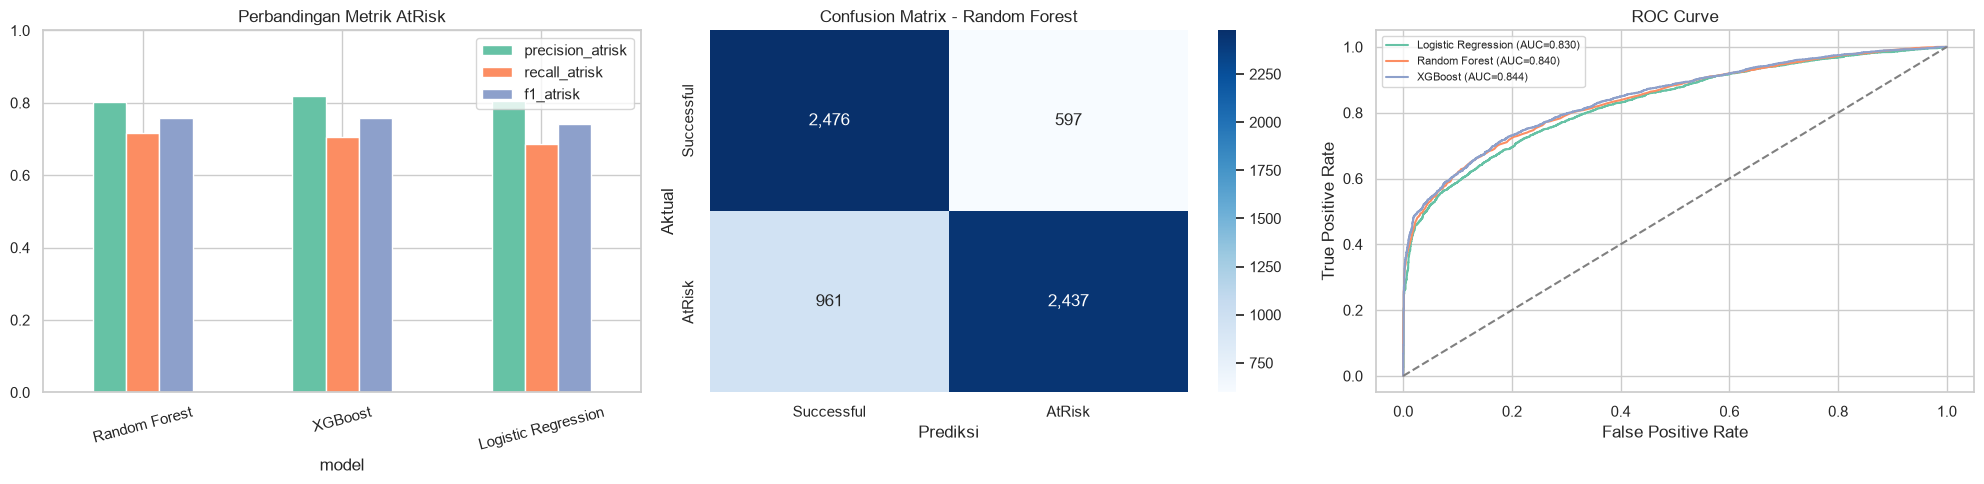

In [11]:
# Siapkan tiga panel visual: perbandingan metrik, confusion matrix, dan ROC curve.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
test_results[['precision_atrisk', 'recall_atrisk', 'f1_atrisk']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Perbandingan Metrik AtRisk'); axes[0].set_ylim(0, 1); axes[0].tick_params(axis='x', rotation=15)

# Confusion matrix menunjukkan kombinasi prediksi benar dan salah untuk model terbaik.
cm_best = confusion_matrix(y_test, best_pred)
sns.heatmap(cm_best, annot=True, fmt=',d', cmap='Blues', ax=axes[1],
            xticklabels=['Successful', 'AtRisk'], yticklabels=['Successful', 'AtRisk'])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

# ROC curve membandingkan kemampuan pemeringkatan risiko dari setiap model.
for name, prob in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
axes[2].plot([0, 1], [0, 1], '--', color='gray')
axes[2].set_title('ROC Curve'); axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. Faktor yang memengaruhi model terbaik

**Tujuan:** memberi transparansi mengenai fitur yang paling berpengaruh.

**Langkah:** mengambil nama fitur setelah preprocessing, kemudian menampilkan feature importance untuk model pohon atau nilai absolut coefficient untuk Logistic Regression.

**Output:** 15 fitur dengan pengaruh terbesar.



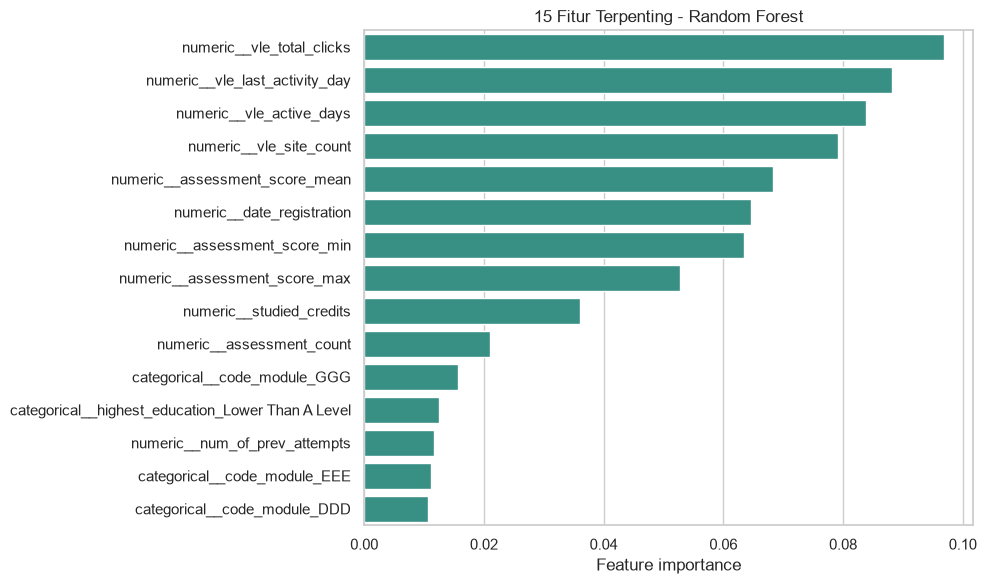

,feature,importance
7,numeric__vle_total_clicks,0.096883
10,numeric__vle_last_activity_day,0.088235
8,numeric__vle_active_days,0.083810
9,numeric__vle_site_count,0.079148
4,numeric__assessment_score_mean,0.068352
2,numeric__date_registration,0.064697
6,numeric__assessment_score_min,0.063415
5,numeric__assessment_score_max,0.052808
1,numeric__studied_credits,0.036006
3,numeric__assessment_count,0.020966


In [12]:
# Ambil nama fitur setelah preprocessing agar importance cocok dengan kolom hasil encoding.
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
estimator = best_model.named_steps['model']
# Model pohon memakai feature_importances_; Logistic Regression memakai absolut koefisien.
if hasattr(estimator, 'feature_importances_'):
    importance_values = estimator.feature_importances_
    importance_label = 'Feature importance'
else:
    importance_values = np.abs(estimator.coef_[0])
    importance_label = 'Absolute coefficient'

# Urutkan 15 fitur teratas untuk visualisasi interpretasi model.
feature_importance = (pd.DataFrame({'feature': feature_names, 'importance': importance_values})
                      .sort_values('importance', ascending=False).head(15))
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', color='#2A9D8F')
plt.title(f'15 Fitur Terpenting - {best_model_name}')
plt.xlabel(importance_label); plt.ylabel(''); plt.tight_layout(); plt.show()
display(feature_importance)

## 13. Knowledge-based risk layer

**Tujuan:** mengubah prediksi model menjadi kategori dan alasan yang operasional.

**Langkah:** threshold perilaku dihitung hanya dari data train menggunakan kuartil bawah. Mahasiswa diberi sinyal risiko, kemudian probabilitas model dan jumlah sinyal digabungkan menjadi `High`, `Medium`, atau `Low Risk`.

**Aturan:** High = model `AtRisk` dan minimal dua sinyal; Medium = model `AtRisk` atau minimal dua sinyal; selain itu Low.

**Output:** threshold, distribusi level, alasan, dan rekomendasi.



In [13]:
# Threshold aturan dihitung dari kuartil bawah data train.
RULE_COLS = ['assessment_score_mean', 'assessment_count', 'vle_total_clicks', 'vle_active_days']
thresholds = X_train[RULE_COLS].quantile(0.25).to_dict()

# Fungsi ini menambahkan prediksi ML, sinyal aturan, level risiko, dan rekomendasi.
def add_knowledge_layer(frame, ml_pred, ml_prob, thresholds):
    result = frame.copy()
    result['predicted_atrisk'] = np.asarray(ml_pred).astype(int)
    result['probability_atrisk'] = np.asarray(ml_prob)
    # Setiap kondisi bernilai True jika perilaku mahasiswa berada di bawah threshold train.
    signal_map = {
        'Skor assessment rendah': result['assessment_score_mean'] <= thresholds['assessment_score_mean'],
        'Partisipasi assessment rendah': result['assessment_count'] <= thresholds['assessment_count'],
        'Total klik VLE rendah': result['vle_total_clicks'] <= thresholds['vle_total_clicks'],
        'Hari aktif VLE rendah': result['vle_active_days'] <= thresholds['vle_active_days']
    }
    result['risk_signal_count'] = sum(condition.astype(int) for condition in signal_map.values())
    result['risk_reasons'] = [
        '; '.join(name for name, condition in signal_map.items() if bool(condition.iloc[i])) or 'Tidak ada sinyal aturan'
        for i in range(len(result))
    ]
    # Aturan level risiko menggabungkan prediksi model dan jumlah sinyal perilaku.
    high = (result['predicted_atrisk'] == 1) & (result['risk_signal_count'] >= 2)
    medium = (result['predicted_atrisk'] == 1) | (result['risk_signal_count'] >= 2)
    result['knowledge_risk_level'] = np.select([high, medium], ['High Risk', 'Medium Risk'], default='Low Risk')

    # Rekomendasi dibuat dari jenis sinyal yang muncul pada tiap mahasiswa.
    def recommendation(row):
        reasons = row['risk_reasons']
        actions = []
        if 'VLE' in reasons: actions.append('pengingat dan monitoring akses VLE')
        if 'assessment' in reasons: actions.append('pendampingan assessment')
        if row['risk_signal_count'] >= 3: actions.append('konseling atau tindak lanjut dosen wali')
        return '; '.join(actions) if actions else 'monitoring rutin'
    result['recommended_action'] = result.apply(recommendation, axis=1)
    return result

# Terapkan knowledge layer pada data test agar hasilnya sejalan dengan evaluasi hold-out.
test_output = dataset.iloc[test_idx].copy().reset_index(drop=True)
test_output = add_knowledge_layer(test_output, best_pred, best_prob, thresholds)
print('Threshold kuartil bawah dari data train:')
display(pd.Series(thresholds, name='threshold').to_frame().round(2))
display(test_output['knowledge_risk_level'].value_counts().to_frame('jumlah'))
display(test_output[['id_student', 'code_module', 'code_presentation', 'probability_atrisk',
                     'knowledge_risk_level', 'risk_reasons', 'recommended_action']].head())

Threshold kuartil bawah dari data train:


,threshold
assessment_score_mean,0.0
assessment_count,0.0
vle_total_clicks,47.0
vle_active_days,4.0


,jumlah
knowledge_risk_level,
Low Risk,2682
Medium Risk,1994
High Risk,1795


,id_student,code_module,code_presentation,probability_atrisk,knowledge_risk_level,risk_reasons,recommended_action
0,11391,AAA,2013J,0.340,Low Risk,Tidak ada sinyal aturan,monitoring rutin
1,38053,AAA,2013J,0.220,Low Risk,Tidak ada sinyal aturan,monitoring rutin
2,52130,AAA,2013J,0.120,Low Risk,Tidak ada sinyal aturan,monitoring rutin
3,63400,AAA,2013J,0.108,Low Risk,Tidak ada sinyal aturan,monitoring rutin
4,74372,AAA,2013J,0.576,Medium Risk,Total klik VLE rendah,pengingat dan monitoring akses VLE


## 14. Evaluasi sistem gabungan

**Tujuan:** mengukur konsekuensi knowledge layer terhadap deteksi risiko.

**Langkah:** `High Risk` dan `Medium Risk` dipetakan menjadi `AtRisk`, lalu metriknya dibandingkan dengan model machine learning terbaik.

**Output:** perubahan recall dan precision setelah aturan ditambahkan.



In [14]:
# Untuk evaluasi biner, High Risk dan Medium Risk diperlakukan sebagai AtRisk.
knowledge_pred = test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']).astype(int)
# Bandingkan metrik model ML murni dengan sistem setelah ditambah knowledge layer.
comparison = pd.DataFrame([
    {'sistem': f'Model ML ({best_model_name})', **calculate_metrics(y_test, best_pred, best_prob)},
    {'sistem': 'Model + Knowledge Layer',
     'accuracy': accuracy_score(y_test, knowledge_pred),
     'precision_atrisk': precision_score(y_test, knowledge_pred, zero_division=0),
     'recall_atrisk': recall_score(y_test, knowledge_pred, zero_division=0),
     'f1_atrisk': f1_score(y_test, knowledge_pred, zero_division=0),
     'roc_auc': np.nan}
]).set_index('sistem')
display(comparison.style.format('{:.4f}', na_rep='-'))
# Confusion matrix tambahan menunjukkan perubahan setelah aturan diterapkan.
print('Confusion matrix knowledge layer:')
display(pd.DataFrame(confusion_matrix(y_test, knowledge_pred),
                     index=['Aktual Successful', 'Aktual AtRisk'],
                     columns=['Prediksi Successful', 'Prediksi AtRisk']))

,accuracy,precision_atrisk,recall_atrisk,f1_atrisk,roc_auc
sistem,,,,,
Model ML (Random Forest),0.7592,0.8032,0.7172,0.7578,0.8396
Model + Knowledge Layer,0.7136,0.7039,0.7849,0.7422,-


Confusion matrix knowledge layer:


,Prediksi Successful,Prediksi AtRisk
Aktual Successful,1951,1122
Aktual AtRisk,731,2667


## 15. Dashboard statis DVBI

**Tujuan:** menyatukan indikator model dan risiko menjadi tampilan monitoring akademik.

**Langkah:** menampilkan KPI, distribusi level, risiko per module-presentation, probabilitas, sinyal dominan, perilaku berdasarkan level, dan confusion matrix.

**Output:** area dengan tingkat risiko tertinggi dan faktor yang membutuhkan intervensi.



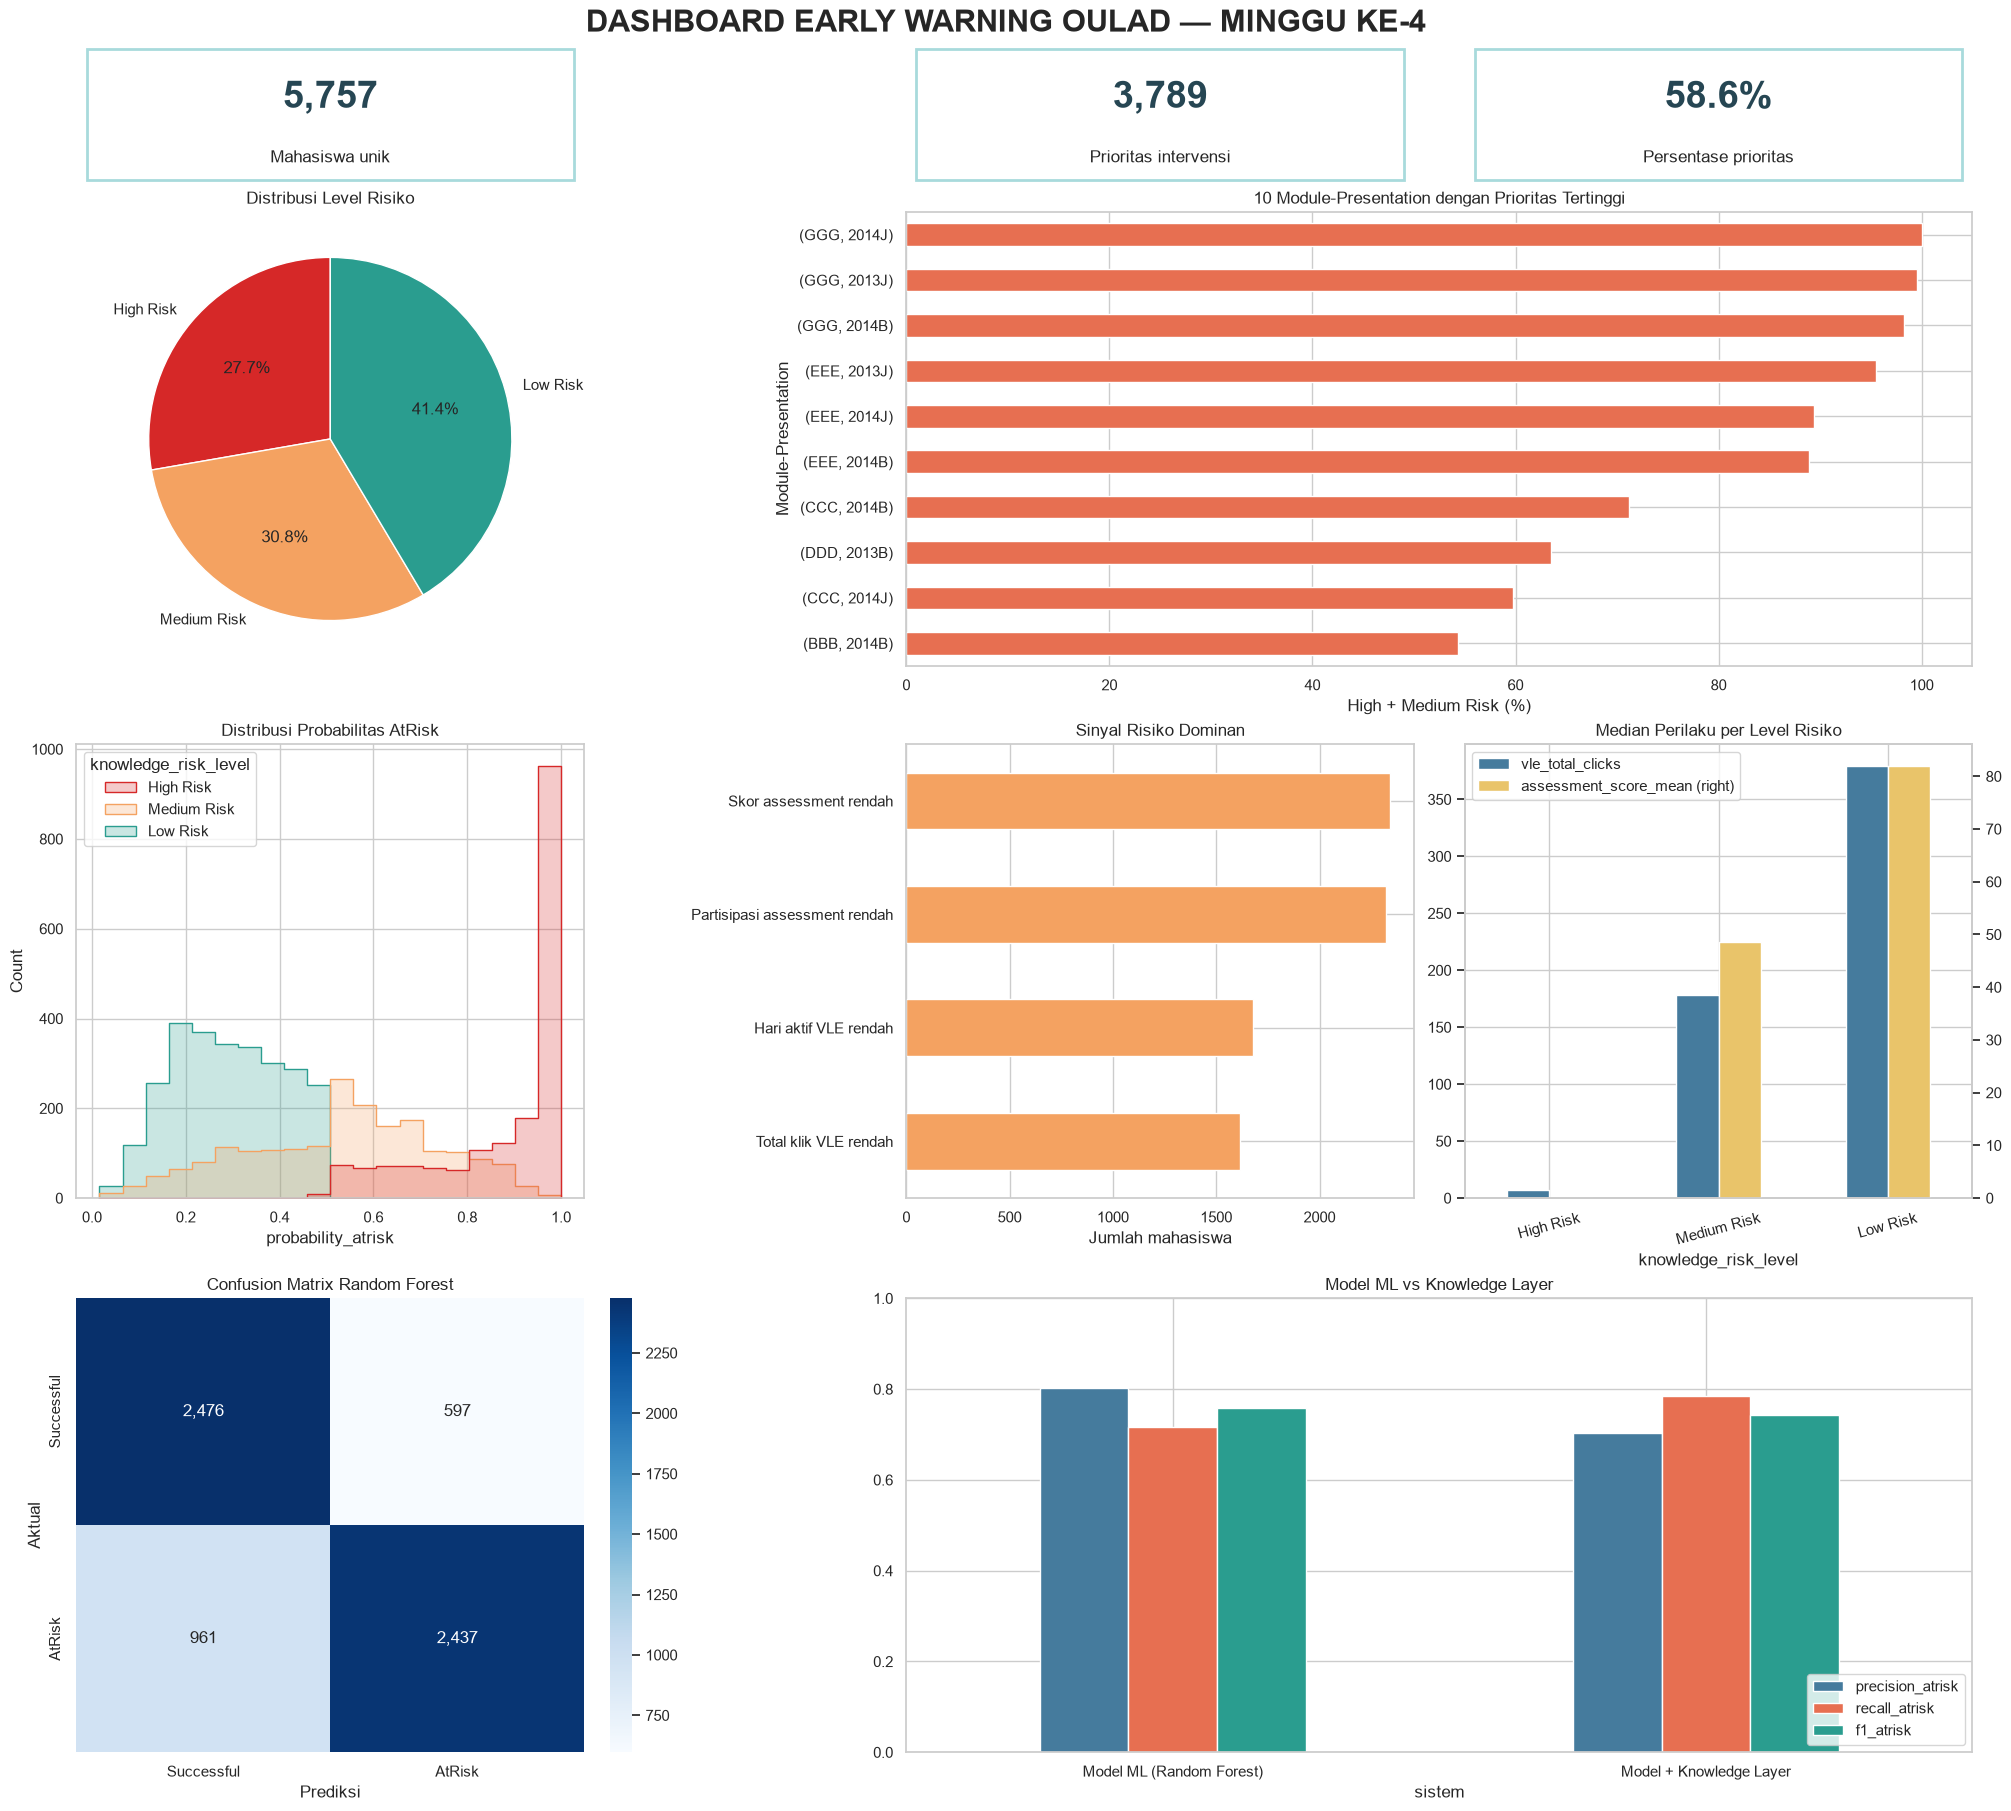

In [15]:
# Tetapkan urutan dan warna level risiko agar semua grafik konsisten.
level_order = ['High Risk', 'Medium Risk', 'Low Risk']
level_colors = {'High Risk': '#D62828', 'Medium Risk': '#F4A261', 'Low Risk': '#2A9D8F'}
level_counts = test_output['knowledge_risk_level'].value_counts().reindex(level_order, fill_value=0)
# Hitung persentase High/Medium Risk per module-presentation.
module_risk = (test_output.assign(is_priority=test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']))
               .groupby(['code_module', 'code_presentation'])['is_priority'].mean()
               .sort_values(ascending=False).head(10).mul(100))
# Pecah alasan risiko menjadi indikator agar sinyal dominan bisa dihitung.
all_signals = (test_output['risk_reasons'].str.get_dummies(sep='; ')
               .drop(columns=['Tidak ada sinyal aturan'], errors='ignore').sum().sort_values(ascending=False))
behavior_level = test_output.groupby('knowledge_risk_level')[
    ['vle_total_clicks', 'assessment_score_mean']].median().reindex(level_order)

# KPI dashboard merangkum jumlah mahasiswa dan antrean prioritas.
total_students = test_output['id_student'].nunique()
priority_count = test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']).sum()
priority_pct = 100 * priority_count / len(test_output)

# Susun dashboard statis dari KPI, distribusi risiko, modul prioritas, dan metrik evaluasi.
fig = plt.figure(figsize=(20, 18), constrained_layout=True)
grid = fig.add_gridspec(4, 3, height_ratios=[0.45, 1.5, 1.5, 1.5])
fig.suptitle('DASHBOARD EARLY WARNING OULAD — MINGGU KE-4', fontsize=22, fontweight='bold')

kpis = [(f'{total_students:,}', 'Mahasiswa unik'), (f'{priority_count:,}', 'Prioritas intervensi'),
        (f'{priority_pct:.1f}%', 'Persentase prioritas')]
for i, (value, label) in enumerate(kpis):
    ax = fig.add_subplot(grid[0, i]); ax.axis('off')
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=27, fontweight='bold', color='#264653')
    ax.text(0.5, 0.18, label, ha='center', va='center', fontsize=12)
    ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False, edgecolor='#A8DADC', linewidth=2))

# Panel risiko: distribusi level dan module-presentation prioritas.
ax1 = fig.add_subplot(grid[1, 0])
ax1.pie(level_counts, labels=level_counts.index, autopct='%1.1f%%', startangle=90,
        colors=[level_colors[x] for x in level_counts.index])
ax1.set_title('Distribusi Level Risiko')

ax2 = fig.add_subplot(grid[1, 1:])
module_risk.sort_values().plot(kind='barh', ax=ax2, color='#E76F51')
ax2.set_title('10 Module-Presentation dengan Prioritas Tertinggi')
ax2.set_xlabel('High + Medium Risk (%)'); ax2.set_ylabel('Module-Presentation')

# Panel perilaku: probabilitas, sinyal dominan, dan median perilaku per level.
ax3 = fig.add_subplot(grid[2, 0])
sns.histplot(data=test_output, x='probability_atrisk', hue='knowledge_risk_level',
             hue_order=level_order, palette=level_colors, bins=20, ax=ax3, element='step')
ax3.set_title('Distribusi Probabilitas AtRisk')

ax4 = fig.add_subplot(grid[2, 1])
all_signals.sort_values().plot(kind='barh', ax=ax4, color='#F4A261')
ax4.set_title('Sinyal Risiko Dominan'); ax4.set_xlabel('Jumlah mahasiswa')

ax5 = fig.add_subplot(grid[2, 2])
behavior_level.plot(kind='bar', ax=ax5, secondary_y='assessment_score_mean', color=['#457B9D', '#E9C46A'])
ax5.set_title('Median Perilaku per Level Risiko'); ax5.tick_params(axis='x', rotation=15)

# Panel evaluasi: confusion matrix dan perbandingan model dengan knowledge layer.
ax6 = fig.add_subplot(grid[3, 0])
sns.heatmap(cm_best, annot=True, fmt=',d', cmap='Blues', ax=ax6,
            xticklabels=['Successful', 'AtRisk'], yticklabels=['Successful', 'AtRisk'])
ax6.set_title(f'Confusion Matrix {best_model_name}'); ax6.set_xlabel('Prediksi'); ax6.set_ylabel('Aktual')

ax7 = fig.add_subplot(grid[3, 1:])
metric_plot = comparison[['precision_atrisk', 'recall_atrisk', 'f1_atrisk']]
metric_plot.plot(kind='bar', ax=ax7, color=['#457B9D', '#E76F51', '#2A9D8F'])
ax7.set_title('Model ML vs Knowledge Layer'); ax7.set_ylim(0, 1); ax7.tick_params(axis='x', rotation=0)
ax7.legend(loc='lower right')
plt.show()

## 16. Daftar prioritas dan insight Business Intelligence

**Tujuan:** menghasilkan informasi yang langsung dapat ditindaklanjuti.

**Langkah:** mengurutkan mahasiswa High Risk berdasarkan probabilitas dan jumlah sinyal, lalu mencetak insight module-presentation serta sinyal dominan secara otomatis.

**Output:** 20 kasus teratas, alasan risiko, dan rekomendasi tindakan.



In [16]:
# Daftar prioritas hanya mengambil mahasiswa dengan High Risk atau Medium Risk.
priority_table = (test_output[test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk'])]
    .sort_values(['knowledge_risk_level', 'probability_atrisk', 'risk_signal_count'],
                 ascending=[True, False, False])
    [['id_student', 'code_module', 'code_presentation', 'probability_atrisk',
      'knowledge_risk_level', 'risk_signal_count', 'risk_reasons', 'recommended_action']])

# Ambil konteks dan sinyal paling menonjol untuk insight BI otomatis.
top_context = module_risk.index[0]
top_signal = all_signals.index[0]
print('INSIGHT BUSINESS INTELLIGENCE')
print(f'1. Prioritas tertinggi: module {top_context[0]} presentation {top_context[1]} '
      f'dengan {module_risk.iloc[0]:.1f}% kasus High/Medium Risk.')
print(f'2. Sinyal risiko paling dominan: {top_signal} ({int(all_signals.iloc[0]):,} kasus).')
print(f'3. Total antrean intervensi: {len(priority_table):,} student-module-presentation.')
print('4. Gunakan alasan risiko bersama probabilitas untuk memilih intervensi.')
print('5. Hasil ini adalah decision support; validasi manusia tetap wajib sebelum tindakan.')

# Tampilkan 20 prioritas teratas sebagai bahan tindak lanjut.
display(priority_table.head(20).style.format({'probability_atrisk': '{:.1%}'}))

INSIGHT BUSINESS INTELLIGENCE
1. Prioritas tertinggi: module GGG presentation 2014J dengan 100.0% kasus High/Medium Risk.
2. Sinyal risiko paling dominan: Skor assessment rendah (2,341 kasus).
3. Total antrean intervensi: 3,789 student-module-presentation.
4. Gunakan alasan risiko bersama probabilitas untuk memilih intervensi.
5. Hasil ini adalah decision support; validasi manusia tetap wajib sebelum tindakan.


,id_student,code_module,code_presentation,probability_atrisk,knowledge_risk_level,risk_signal_count,risk_reasons,recommended_action
170,87604,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
171,88580,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
180,185240,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
186,230348,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
187,258402,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
189,269289,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
201,323914,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
209,353918,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
211,357038,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
220,372624,BBB,2013B,100.0%,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali


## 17. Ekspor hasil untuk pelaporan

**Tujuan:** menyimpan keluaran yang dapat digunakan dalam laporan atau analisis lanjutan.

**Langkah:** menyimpan metrik model dan daftar prioritas sebagai CSV di runtime Colab.

**Output:** lokasi file hasil.



In [17]:
# Folder output dibuat di runtime Colab.
OUTPUT_DIR = Path('/content/oulad_dvbi_output')
OUTPUT_DIR.mkdir(exist_ok=True)
# Simpan metrik model, evaluasi knowledge layer, dan daftar prioritas ke CSV.
test_results.reset_index().to_csv(OUTPUT_DIR / 'model_evaluation.csv', index=False)
comparison.reset_index().to_csv(OUTPUT_DIR / 'knowledge_layer_evaluation.csv', index=False)
priority_table.to_csv(OUTPUT_DIR / 'intervention_priority.csv', index=False)
# Cetak lokasi dan nama file agar mudah diunduh dari Colab.
print('Output tersimpan di:', OUTPUT_DIR)
print([p.name for p in OUTPUT_DIR.iterdir()])

Output tersimpan di: /content/oulad_dvbi_output
['intervention_priority.csv', 'model_evaluation.csv', 'knowledge_layer_evaluation.csv']


## 18. Kesimpulan dan keterbatasan

**Kesimpulan:** notebook membandingkan tiga model pada skenario early warning minggu ke-4. Model dipilih berdasarkan recall `AtRisk`, lalu knowledge-based layer menambahkan level risiko, alasan, dan rekomendasi. Dashboard menerjemahkan keluaran tersebut menjadi monitoring dan prioritas intervensi.

**Keterbatasan:**
- Label berasal dari hasil akhir, sedangkan prediktor dibatasi sampai hari ke-28.
- Threshold kuartil merupakan baseline berbasis data dan perlu divalidasi pakar akademik.
- Recall tinggi dapat meningkatkan false positive dan beban intervensi.
- OULAD berasal dari konteks Open University di Inggris sehingga penerapan pada institusi lain memerlukan validasi ulang.
- Feature importance menunjukkan kontribusi prediktif dan ditafsirkan sebagai asosiasi dalam model.

